In [2]:
pip install duckdb


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('charts', exist_ok=True)

# Create a persistent DuckDB database file
con = duckdb.connect('../data/olist.duckdb')

# Register all 6 CSVs as views — DuckDB reads them directly, no loading needed
con.execute("""
    CREATE OR REPLACE VIEW orders AS
    SELECT * FROM read_csv_auto('../data/olist_orders_dataset.csv');
""")
con.execute("""
    CREATE OR REPLACE VIEW customers AS
    SELECT * FROM read_csv_auto('../data/olist_customers_dataset.csv');
""")
con.execute("""
    CREATE OR REPLACE VIEW items AS
    SELECT * FROM read_csv_auto('../data/olist_order_items_dataset.csv');
""")
con.execute("""
    CREATE OR REPLACE VIEW products AS
    SELECT * FROM read_csv_auto('../data/olist_products_dataset.csv');
""")
con.execute("""
    CREATE OR REPLACE VIEW payments AS
    SELECT * FROM read_csv_auto('../data/olist_order_payments_dataset.csv');
""")
con.execute("""
    CREATE OR REPLACE VIEW reviews AS
    SELECT * FROM read_csv_auto('../data/olist_order_reviews_dataset.csv');
""")

print("✓ All 6 tables registered as DuckDB views")

# Verify row counts with SQL
con.execute("""
    SELECT 'orders'    AS tbl, COUNT(*) AS rows FROM orders    UNION ALL
    SELECT 'customers',        COUNT(*)          FROM customers UNION ALL
    SELECT 'items',            COUNT(*)          FROM items     UNION ALL
    SELECT 'products',         COUNT(*)          FROM products  UNION ALL
    SELECT 'payments',         COUNT(*)          FROM payments  UNION ALL
    SELECT 'reviews',          COUNT(*)          FROM reviews
""").df()

✓ All 6 tables registered as DuckDB views


,tbl,rows
0,orders,99441
1,customers,99441
2,items,112650
3,products,32951
4,payments,103886
5,reviews,99224


In [4]:
master = con.execute("""
    WITH

    -- Aggregate payments per order
    pay_agg AS (
        SELECT
            order_id,
            ROUND(SUM(payment_value), 2)   AS total_payment,
            MAX(payment_installments)       AS max_installments,
            FIRST(payment_type)             AS payment_type
        FROM payments
        GROUP BY order_id
    ),

    -- Aggregate items per order
    item_agg AS (
        SELECT
            order_id,
            COUNT(order_item_id)            AS total_items,
            ROUND(SUM(price), 2)            AS total_price,
            ROUND(SUM(freight_value), 2)    AS total_freight,
            ROUND(AVG(price), 2)            AS avg_item_price
        FROM items
        GROUP BY order_id
    ),

    -- Primary product category per order (most expensive item)
    primary_cat AS (
        SELECT DISTINCT ON (i.order_id)
            i.order_id,
            p.product_category_name         AS primary_category
        FROM items i
        LEFT JOIN products p ON i.product_id = p.product_id
        ORDER BY i.order_id, i.price DESC
    ),

    -- Average review score per order
    rev_agg AS (
        SELECT
            order_id,
            ROUND(AVG(review_score), 2)     AS review_score
        FROM reviews
        GROUP BY order_id
    )

    -- Final join — everything onto orders
    SELECT
        o.order_id,
        o.customer_id,
        o.order_status,

        -- Timestamps
        o.order_purchase_timestamp::TIMESTAMP       AS purchased_at,
        o.order_approved_at::TIMESTAMP              AS approved_at,
        o.order_delivered_carrier_date::TIMESTAMP   AS shipped_at,
        o.order_delivered_customer_date::TIMESTAMP  AS delivered_at,
        o.order_estimated_delivery_date::TIMESTAMP  AS estimated_at,

        -- Derived time fields
        YEAR(o.order_purchase_timestamp::TIMESTAMP)  AS purchase_year,
        MONTH(o.order_purchase_timestamp::TIMESTAMP) AS purchase_month,
        DAYNAME(o.order_purchase_timestamp::TIMESTAMP) AS purchase_dow,
        STRFTIME(o.order_purchase_timestamp::TIMESTAMP, '%Y-%m') AS yearmon,

        -- Delivery metrics
        DATEDIFF('day',
            o.order_purchase_timestamp::TIMESTAMP,
            o.order_delivered_customer_date::TIMESTAMP
        )                                           AS delivery_days,
        DATEDIFF('day',
            o.order_estimated_delivery_date::TIMESTAMP,
            o.order_delivered_customer_date::TIMESTAMP
        )                                           AS delivery_delta,

        -- Customer location
        c.customer_state,
        c.customer_city,

        -- Payment metrics
        pa.total_payment,
        pa.max_installments,
        pa.payment_type,

        -- Item metrics
        ia.total_items,
        ia.total_price,
        ia.total_freight,
        ia.avg_item_price,

        -- Product category
        pc.primary_category,

        -- Review
        ra.review_score

    FROM orders o
    LEFT JOIN customers  c  ON o.customer_id = c.customer_id
    LEFT JOIN pay_agg    pa ON o.order_id     = pa.order_id
    LEFT JOIN item_agg   ia ON o.order_id     = ia.order_id
    LEFT JOIN primary_cat pc ON o.order_id   = pc.order_id
    LEFT JOIN rev_agg    ra ON o.order_id     = ra.order_id

""").df()

print(f"Master table: {master.shape[0]:,} rows × {master.shape[1]} cols")
master.head(3)

Master table: 99,441 rows × 25 cols


,order_id,customer_id,order_status,purchased_at,approved_at,shipped_at,delivered_at,estimated_at,purchase_year,purchase_month,...,customer_city,total_payment,max_installments,payment_type,total_items,total_price,total_freight,avg_item_price,primary_category,review_score
0,f8868b8046c99c3b68a17b935efe47a9,d2d16e9dd973b2b3d164d55bdd6f7614,delivered,2018-06-21 02:36:49,2018-06-22 02:58:55,2018-06-22 13:56:00,2018-06-29 19:06:54,2018-07-19,2018,6,...,uberaba,199.43,1,boleto,1,109.99,89.44,109.99,cama_mesa_banho,3.0
1,8c46c4b2bbf318ff31368bc87309662e,80326990ee607892a2a6c4c8baca53fd,delivered,2017-02-05 22:32:10,2017-02-05 22:42:00,2017-02-06 14:04:55,2017-02-16 14:22:49,2017-03-15,2017,2,...,carajas,206.61,2,credit_card,1,159.00,47.61,159.00,esporte_lazer,5.0
2,ddd1cd1f0c2ecee8f709cd6c8d22daab,2cb427e402525a74cbec079d7b9be168,delivered,2018-07-24 11:07:22,2018-07-24 11:44:45,2018-07-24 16:25:00,2018-07-31 18:36:27,2018-08-14,2018,7,...,araruama,99.75,4,credit_card,1,80.00,19.75,80.00,construcao_ferramentas_construcao,5.0


In [5]:
# Register master dataframe as a DuckDB view
con.register('master', master)

# Filter to delivered orders 2017-2018 using SQL
delivered = con.execute("""
    SELECT *
    FROM master
    WHERE order_status    = 'delivered'
      AND purchase_year   IN (2017, 2018)
      AND total_payment   IS NOT NULL
""").df()

# Register delivered too
con.register('delivered', delivered)

print(f"Delivered orders (2017–2018) : {len(delivered):,}")

# Summary stats — pure SQL
con.execute("""
    SELECT
        COUNT(*)                        AS total_orders,
        ROUND(SUM(total_payment), 0)    AS total_revenue,
        ROUND(AVG(total_payment), 2)    AS avg_order_value,
        ROUND(AVG(delivery_days), 1)    AS avg_delivery_days,
        ROUND(AVG(review_score), 2)     AS avg_review_score
    FROM delivered
""").df()

Delivered orders (2017–2018) : 96,211


,total_orders,total_revenue,avg_order_value,avg_delivery_days,avg_review_score
0,96211,15375875.0,159.81,12.5,4.16


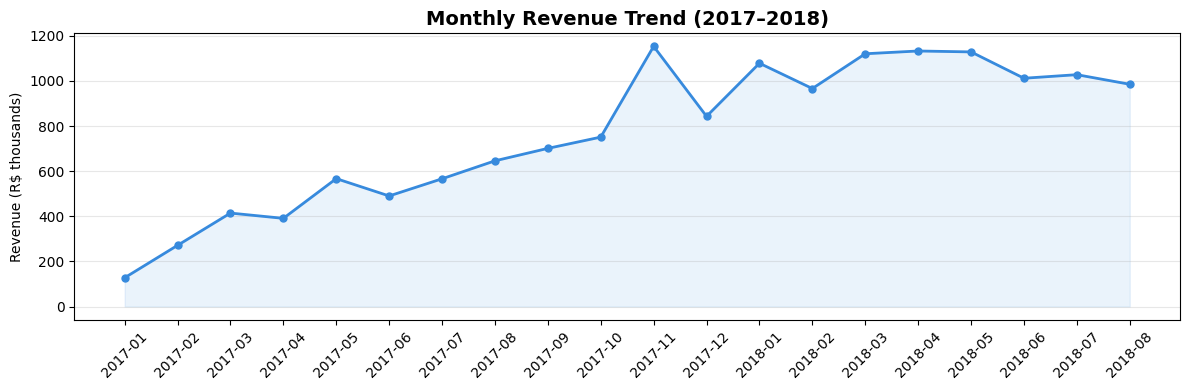

Peak month: 2017-11 — R$1,153,528


In [6]:
monthly_rev = con.execute("""
    SELECT
        yearmon,
        COUNT(order_id)                 AS total_orders,
        ROUND(SUM(total_payment), 0)    AS revenue,
        ROUND(AVG(total_payment), 2)    AS avg_order_value
    FROM delivered
    GROUP BY yearmon
    ORDER BY yearmon
""").df()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_rev['yearmon'],
        monthly_rev['revenue'] / 1000,
        marker='o', linewidth=2, color='#378ADD', markersize=5)
ax.fill_between(monthly_rev['yearmon'],
                monthly_rev['revenue'] / 1000,
                alpha=0.1, color='#378ADD')
ax.set_title('Monthly Revenue Trend (2017–2018)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (R$ thousands)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/01_monthly_revenue.png', dpi=150)
plt.show()

peak = monthly_rev.loc[monthly_rev['revenue'].idxmax()]
print(f"Peak month: {peak['yearmon']} — R${peak['revenue']:,.0f}")

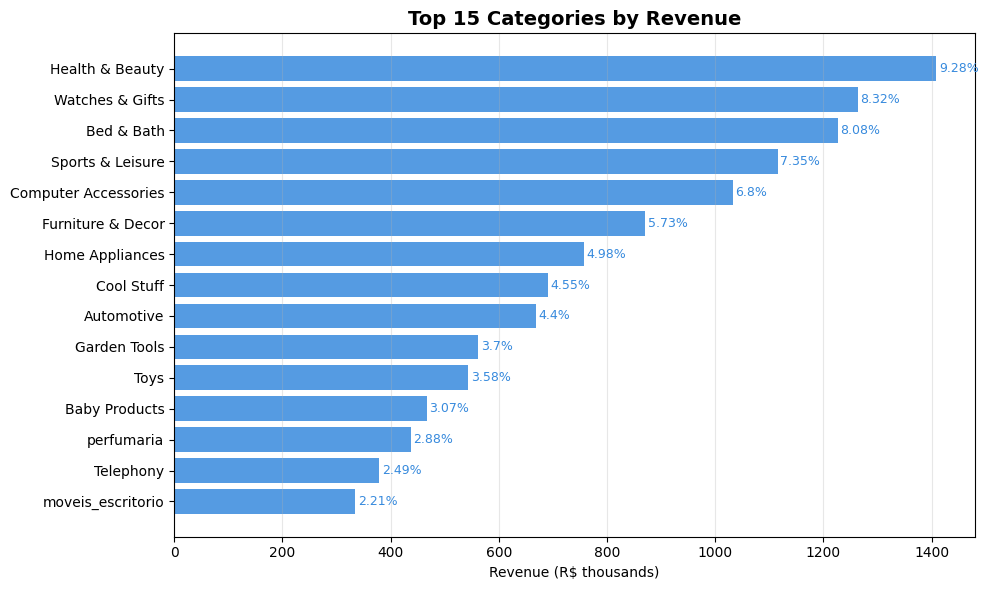

In [7]:
# Window function to calculate revenue share — this is what separates
# junior SQL from senior SQL
cat_rev = con.execute("""
    SELECT
        primary_category,
        COUNT(order_id)                              AS total_orders,
        ROUND(SUM(total_payment), 0)                 AS revenue,
        ROUND(AVG(total_payment), 2)                 AS avg_order_value,
        ROUND(
            100.0 * SUM(total_payment)
            / SUM(SUM(total_payment)) OVER (),
        2)                                           AS revenue_share_pct
    FROM delivered
    WHERE primary_category IS NOT NULL
    GROUP BY primary_category
    ORDER BY revenue DESC
    LIMIT 15
""").df()

# Translate from Portuguese
translations = {
    'beleza_saude'            : 'Health & Beauty',
    'informatica_acessorios'  : 'Computer Accessories',
    'automotivo'              : 'Automotive',
    'cama_mesa_banho'         : 'Bed & Bath',
    'moveis_decoracao'        : 'Furniture & Decor',
    'esporte_lazer'           : 'Sports & Leisure',
    'utilidades_domesticas'   : 'Home Appliances',
    'relogios_presentes'      : 'Watches & Gifts',
    'telefonia'               : 'Telephony',
    'ferramentas_jardim'      : 'Garden Tools',
    'cool_stuff'              : 'Cool Stuff',
    'eletronicos'             : 'Electronics',
    'bebes'                   : 'Baby Products',
    'eletrodomesticos'        : 'Home Electronics',
    'brinquedos'              : 'Toys',
}
cat_rev['category_en'] = (cat_rev['primary_category']
                          .map(translations)
                          .fillna(cat_rev['primary_category']))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cat_rev['category_en'],
        cat_rev['revenue'] / 1000,
        color='#378ADD', alpha=0.85)
ax.set_title('Top 15 Categories by Revenue',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (R$ thousands)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add revenue share labels
for i, row in cat_rev.iterrows():
    ax.text(row['revenue']/1000 + 5, i,
            f"{row['revenue_share_pct']}%",
            va='center', fontsize=9,
            color='#378ADD')

plt.tight_layout()
plt.savefig('charts/02_revenue_by_category.png', dpi=150)
plt.show()

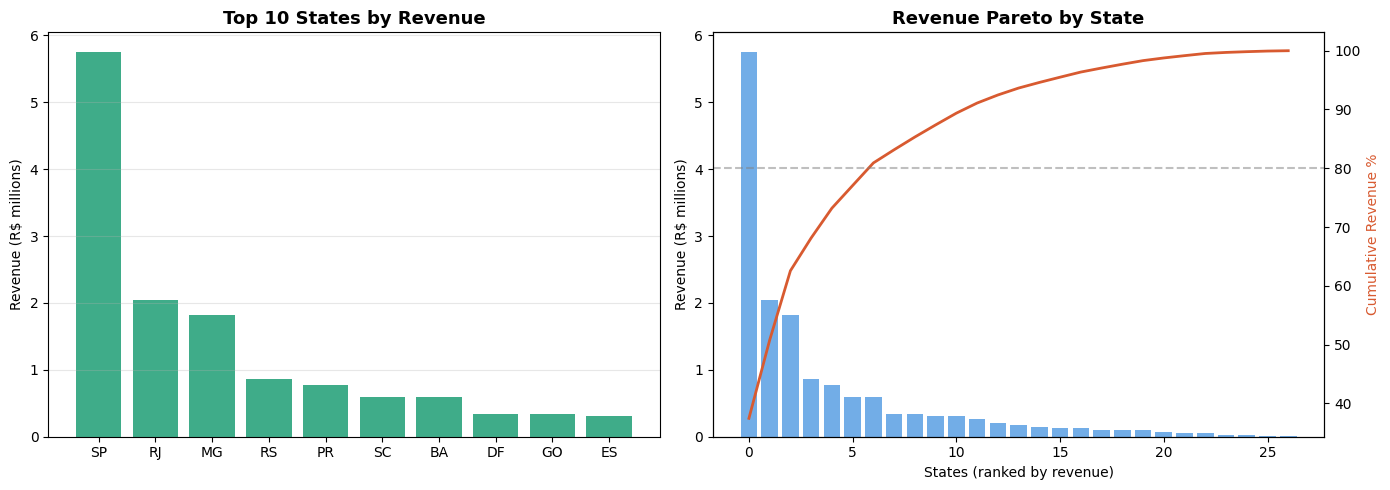

Top 6 states drive 80% of all revenue
SP revenue share: 37.44%


In [8]:
state_rev = con.execute("""
    SELECT
        customer_state,
        COUNT(order_id)                             AS total_orders,
        ROUND(SUM(total_payment), 0)                AS revenue,
        ROUND(AVG(total_payment), 2)                AS avg_order_value,
        ROUND(AVG(review_score), 2)                 AS avg_review,
        ROUND(
            100.0 * SUM(total_payment)
            / SUM(SUM(total_payment)) OVER (),
        2)                                          AS revenue_share_pct,
        -- Running total
        ROUND(
            SUM(SUM(total_payment))
            OVER (ORDER BY SUM(total_payment) DESC),
        0)                                          AS running_revenue
    FROM delivered
    GROUP BY customer_state
    ORDER BY revenue DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(state_rev.head(10)['customer_state'],
            state_rev.head(10)['revenue'] / 1e6,
            color='#1D9E75', alpha=0.85)
axes[0].set_title('Top 10 States by Revenue',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (R$ millions)')
axes[0].grid(axis='y', alpha=0.3)

# Pareto — cumulative revenue share
cumulative_pct = (state_rev['revenue'].cumsum()
                  / state_rev['revenue'].sum() * 100)
axes[1].bar(range(len(state_rev)), state_rev['revenue']/1e6,
            color='#378ADD', alpha=0.7)
ax2 = axes[1].twinx()
ax2.plot(range(len(state_rev)), cumulative_pct,
         color='#D85A30', linewidth=2, marker='')
ax2.axhline(y=80, color='gray', linestyle='--',
            alpha=0.5, label='80% revenue')
ax2.set_ylabel('Cumulative Revenue %', color='#D85A30')
axes[1].set_title('Revenue Pareto by State',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('States (ranked by revenue)')
axes[1].set_ylabel('Revenue (R$ millions)')

plt.tight_layout()
plt.savefig('charts/03_revenue_by_state.png', dpi=150)
plt.show()

# How many states make up 80% of revenue?
states_80 = (cumulative_pct <= 80).sum()
print(f"Top {states_80} states drive 80% of all revenue")
print(f"SP revenue share: {state_rev.iloc[0]['revenue_share_pct']}%")

delivery_bucket  orders  avg_review  avg_order_value
 >10 days early   56652        4.32           164.06
5-10 days early   22437        4.28           149.28
 0-5 days early    8813        4.15           146.51
  0-5 days late    3567        3.46           159.09
 5-10 days late    1861        1.89           181.18
  >10 days late    2230        1.70           182.70


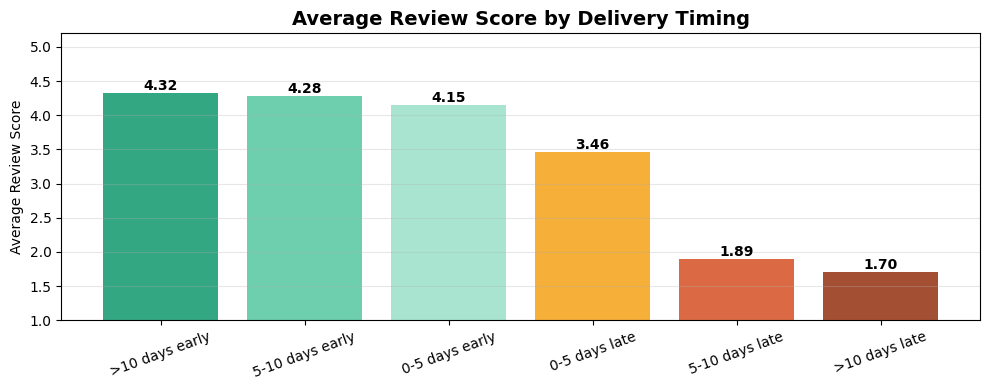

In [9]:
delivery_analysis = con.execute("""
    SELECT
        CASE
            WHEN delivery_delta < -10 THEN '>10 days early'
            WHEN delivery_delta < -5  THEN '5-10 days early'
            WHEN delivery_delta < 0   THEN '0-5 days early'
            WHEN delivery_delta < 5   THEN '0-5 days late'
            WHEN delivery_delta < 10  THEN '5-10 days late'
            ELSE '>10 days late'
        END                             AS delivery_bucket,
        COUNT(*)                        AS orders,
        ROUND(AVG(review_score), 2)     AS avg_review,
        ROUND(AVG(total_payment), 2)    AS avg_order_value
    FROM delivered
    WHERE delivery_delta IS NOT NULL
      AND review_score   IS NOT NULL
    GROUP BY delivery_bucket
    ORDER BY MIN(delivery_delta)
""").df()

print(delivery_analysis.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#1D9E75','#5DCAA5','#9FE1CB',
          '#F5A623','#D85A30','#993C1D']
bars = ax.bar(delivery_analysis['delivery_bucket'],
              delivery_analysis['avg_review'],
              color=colors, alpha=0.9)
ax.set_title('Average Review Score by Delivery Timing',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Average Review Score')
ax.set_ylim(1, 5.2)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, delivery_analysis['avg_review']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}', ha='center',
            fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/04_review_by_delivery.png', dpi=150)
plt.show()

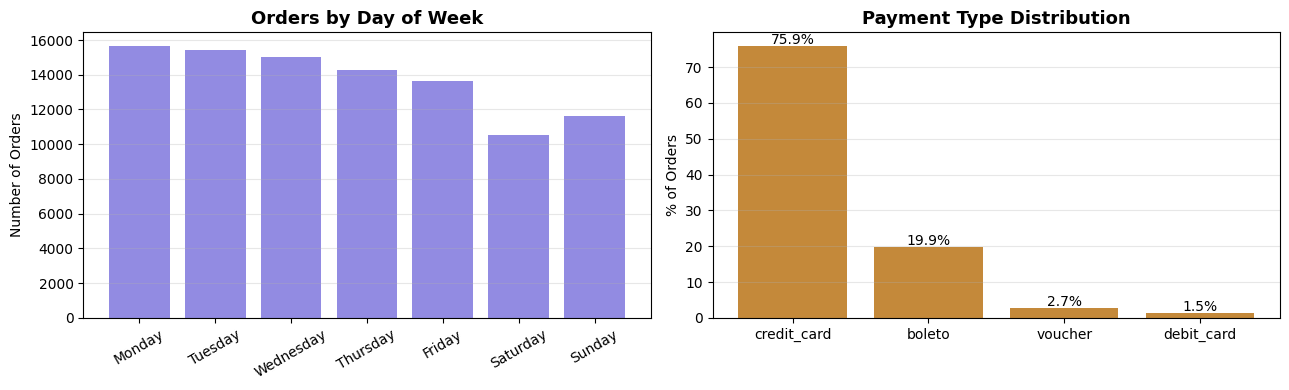

In [10]:
# Orders and revenue by day of week
dow = con.execute("""
    SELECT
        purchase_dow,
        COUNT(order_id)              AS orders,
        ROUND(SUM(total_payment), 0) AS revenue,
        ROUND(AVG(total_payment), 2) AS avg_order_value
    FROM delivered
    GROUP BY purchase_dow
    ORDER BY orders DESC
""").df()

# Payment type breakdown
pay_type = con.execute("""
    SELECT
        payment_type,
        COUNT(*)                                    AS orders,
        ROUND(SUM(total_payment), 0)                AS revenue,
        ROUND(
            100.0 * COUNT(*)
            / SUM(COUNT(*)) OVER (),
        1)                                          AS pct_orders
    FROM delivered
    GROUP BY payment_type
    ORDER BY orders DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sort days properly
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
dow['purchase_dow'] = pd.Categorical(
    dow['purchase_dow'], categories=day_order, ordered=True)
dow = dow.sort_values('purchase_dow')

axes[0].bar(dow['purchase_dow'], dow['orders'],
            color='#7F77DD', alpha=0.85)
axes[0].set_title('Orders by Day of Week',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(pay_type['payment_type'],
            pay_type['pct_orders'],
            color='#BA7517', alpha=0.85)
axes[1].set_title('Payment Type Distribution',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('% of Orders')
for i, row in pay_type.iterrows():
    axes[1].text(i, row['pct_orders'] + 0.5,
                 f"{row['pct_orders']}%",
                 ha='center', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('charts/05_dow_payment.png', dpi=150)
plt.show()

In [11]:
# Save as parquet — much faster to read than CSV for future phases
con.execute("""
    COPY (SELECT * FROM master)
    TO '../data/master_orders.parquet' (FORMAT PARQUET)
""")

con.execute("""
    COPY (SELECT * FROM delivered)
    TO '../data/delivered_orders.parquet' (FORMAT PARQUET)
""")

print("✓ Master table saved as Parquet")
print("✓ Delivered table saved as Parquet")
print("✓ DuckDB database saved to data/olist.duckdb")
print()

# Final summary query
con.execute("""
    SELECT
        COUNT(*)                     AS total_orders,
        COUNT(DISTINCT customer_id)  AS unique_customers,
        COUNT(DISTINCT customer_state) AS states_covered,
        ROUND(SUM(total_payment), 0) AS total_revenue,
        ROUND(AVG(total_payment), 2) AS avg_order_value,
        ROUND(AVG(delivery_days), 1) AS avg_delivery_days,
        ROUND(AVG(review_score), 2)  AS avg_review_score
    FROM delivered
""").df()

✓ Master table saved as Parquet
✓ Delivered table saved as Parquet
✓ DuckDB database saved to data/olist.duckdb



,total_orders,unique_customers,states_covered,total_revenue,avg_order_value,avg_delivery_days,avg_review_score
0,96211,96211,27,15375875.0,159.81,12.5,4.16
